In [1]:
"""This code compare VR methods to BSPPA with constant steps. One can see the effects of the variance of BSPPA.  At the moment the experiment is still
on going to make different tests.
"""

import numpy as np
import matplotlib.pyplot as plt
import time

def kl_row_loss(z, b_i):
    z = max(z, 1e-15)
    if b_i <= 0:
        return z
    return b_i * np.log(b_i / z) - b_i + z


def objective(A, b, x):
    Ax = A @ x
    if np.any(Ax <= 0):
        return np.inf
    return np.mean([kl_row_loss(Ax[i], b[i]) for i in range(len(b))])


def grad_f_i(A, b, x, i):
    """
    ∇f_i(x) = (1 - b_i / (a_i^T x)) a_i
    """
    ai = A[i]
    z = ai @ x
    z = max(z, 1e-15)
    return (1.0 - b[i] / z) * ai

def full_gradient(A, b, x, eps=1e-15):
    """
    Full gradient for

        F(x) = (1/n) Σ_i [ b_i log(b_i/(Ax)_i) - b_i + (Ax)_i ]

    Parameters
    ----------
    A : ndarray (n, d)
    b : ndarray (n,)
    x : ndarray (d,)
    eps : float
        Numerical safeguard.

    Returns
    -------
    grad : ndarray (d,)
    """
    Ax = A @ x
    Ax = np.maximum(Ax, eps)

    coeff = 1.0 - b / Ax
    grad = A.T @ coeff

    return grad / A.shape[0]

def solve_subproblem(ai, b_i, xk, correction, gamma, tol=1e-12, max_iter=100):
    """
    Solve the implicit Bregman-VR step

        ∇h(x+) = ∇h(xk) - γ( ∇f_i(x+) + correction )

    where
        h(x) = -Σ log x_j
        ∇f_i(x) = a_i - (b_i / (a_i^T x)) a_i

    and correction is the constant vector
        correction = -∇f_i(x_tilde) + ∇F(x_tilde)

    This yields
        1/x+ = c - λ a_i
    with
        c = 1/xk + γ(a_i + correction)
        λ = γ b_i / (a_i^T x+)

    so λ solves
        λ Σ_j a_ij / (c_j - λ a_ij) = γ b_i.
    """
    ai = np.asarray(ai, dtype=float)
    xk = np.asarray(xk, dtype=float)
    correction = np.asarray(correction, dtype=float)

    c = 1.0 / xk + gamma * (ai + correction)

    if np.any(c <= 0):
        raise RuntimeError("Nonpositive c encountered. Try a smaller stepsize.")

    if b_i <= 0:
        return 1.0 / c

    support = ai > 0
    if not np.any(support):
        return 1.0 / c
        
    # solving 1-d root finding problem phi(lam) = 0
    def phi(lam):
        denom = c - lam * ai
        return lam * np.sum(ai[support] / denom[support]) - gamma * b_i

    lam_hi = np.min(c[support] / ai[support])
    lo = 0.0
    hi = lam_hi * (1.0 - 1e-12)

    fhi = phi(hi)
    shrink = 0
    while (not np.isfinite(fhi) or fhi <= 0) and shrink < 60:
        hi *= 0.5
        fhi = phi(hi)
        shrink += 1

    if not np.isfinite(fhi) or fhi <= 0:
        raise RuntimeError("Could not bracket the scalar root. Try a smaller stepsize.")

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        fm = phi(mid)
        if abs(fm) <= tol:
            lam = mid
            break
        if fm > 0:
            hi = mid
        else:
            lo = mid
    else:
        lam = 0.5 * (lo + hi)

    denom = c - lam * ai
    if np.any(denom <= 0):
        raise RuntimeError("Implicit step failed: nonpositive denominator.")

    return 1.0 / denom


def bregman_sapa_kl(
    A,
    b,
    x0,
    stepsize=1e-3,
    max_epochs=100,
    time_budget_seconds=None,
    seed=0,
    store_history=True,
    verbose=False,
):
    """
    Implicit Bregman-SAPA. If time_budget_seconds is not None, run until the
    wall-clock budget is reached instead of using max_epochs as the stopping rule.
    """
    rng = np.random.default_rng(seed)

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    x = np.asarray(x0, dtype=float).copy()

    n, d = A.shape

    if x.shape != (d,):
        raise ValueError(f"x0 must have shape ({d},), got {x.shape}")
    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive")
    if np.any(A < 0):
        raise ValueError("This implementation assumes A >= 0.")
    if np.any(b < 0):
        raise ValueError("b must be nonnegative")

    grad_table = np.zeros((n, d), dtype=float)
    mean_grad = np.zeros(d, dtype=float)

    for i in range(n):
        gi = grad_f_i(A, b, x, i)
        grad_table[i] = gi
        mean_grad += gi
    mean_grad /= n

    history = {"obj": [], "x": [], "time": []} if store_history else None
    start_time = time.perf_counter()

    if store_history:
        history["obj"].append(objective(A, b, x))
        history["x"].append(x.copy())
        history["time"].append(0.0)

    total_iters = 3 * max_epochs * n - n
    k = 0

    while True:
        if time_budget_seconds is not None and (time.perf_counter() - start_time) >= time_budget_seconds:
            break
        if time_budget_seconds is None and k >= total_iters:
            break

        i = rng.integers(n)
        ai = A[i]
        alpha_i = grad_table[i].copy()

        x_new = solve_subproblem(
            ai=ai,
            b_i=b[i],
            xk=x,
            correction=-alpha_i + mean_grad,
            gamma=stepsize,
        )

        gi_new = grad_f_i(A, b, x_new, i)
        mean_grad += (gi_new - grad_table[i]) / n
        grad_table[i] = gi_new
        x = x_new
        k += 1

        if store_history and ((k % n) == 0):
            elapsed = time.perf_counter() - start_time
            fval = objective(A, b, x)
            history["obj"].append(fval)
            history["x"].append(x.copy())
            history["time"].append(elapsed)
            if verbose:
                print(f"time={elapsed:8.3f}s, epoch={k // n:4d}, obj={fval:.8e}")

    return x, history


def bregman_svrp_kl(
    A,
    b,
    x0,
    stepsize=1e-3,
    max_epochs=50,
    inner_steps=None,
    time_budget_seconds=None,
    seed=0,
    store_history=True,
    verbose=False,
):
    """
    Implicit Bregman-SVRP. If time_budget_seconds is not None, run until the
    wall-clock budget is reached. The budget is checked both between outer
    epochs and inside the inner loop because this method has a nested loop.
    """
    rng = np.random.default_rng(seed)

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    x = np.asarray(x0, dtype=float).copy()

    n, d = A.shape

    if x.shape != (d,):
        raise ValueError(f"x0 must have shape ({d},), got {x.shape}")
    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive")
    if np.any(A < 0):
        raise ValueError("This implementation assumes A >= 0.")
    if np.any(b < 0):
        raise ValueError("b must be nonnegative")

    if inner_steps is None:
        inner_steps = n

    history = {"obj": [], "x": [], "time": []} if store_history else None
    start_time = time.perf_counter()

    if store_history:
        history["obj"].append(objective(A, b, x))
        history["x"].append(x.copy())
        history["time"].append(0.0)

    epoch = 0
    while True:
        if time_budget_seconds is not None and (time.perf_counter() - start_time) >= time_budget_seconds:
            break
        if time_budget_seconds is None and epoch >= max_epochs:
            break

        x_tilde = x.copy()
        g_tilde = full_gradient(A, b, x_tilde)
        x_inner = x_tilde.copy()

        for _ in range(inner_steps):
            if time_budget_seconds is not None and (time.perf_counter() - start_time) >= time_budget_seconds:
                break
            i = rng.integers(n)
            ai = A[i]

            grad_i_tilde = grad_f_i(A, b, x_tilde, i)
            correction = -grad_i_tilde + g_tilde

            x_inner = solve_subproblem(
                ai=ai,
                b_i=b[i],
                xk=x_inner,
                correction=correction,
                gamma=stepsize,
            )

        x = x_inner
        epoch += 1

        if store_history:
            elapsed = time.perf_counter() - start_time
            fval = objective(A, b, x)
            history["obj"].append(fval)
            history["x"].append(x.copy())
            history["time"].append(elapsed)

        if verbose:
            print(f"time={elapsed:8.3f}s, epoch={epoch:4d}, obj={fval:.8e}")

    return x, history

def bregman_sppa_kl(
    A,
    b,
    x0,
    stepsize=1e-3,
    max_epochs=100,
    time_budget_seconds=None,
    seed=0,
    store_history=True,
    verbose=False,
    vanishing=True
):
    """
    Implicit stochastic Bregman method. If time_budget_seconds is not None,
    run until the wall-clock budget is reached instead of using max_epochs.
    """
    rng = np.random.default_rng(seed)

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    x = np.asarray(x0, dtype=float).copy()

    n, d = A.shape

    if x.shape != (d,):
        raise ValueError(f"x0 must have shape ({d},), got {x.shape}")
    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive")
    if np.any(A < 0):
        raise ValueError("This implementation assumes A >= 0.")
    if np.any(b < 0):
        raise ValueError("b must be nonnegative")

    history = {"obj": [], "x": [], "time": []} if store_history else None
    start_time = time.perf_counter()

    if store_history:
        history["obj"].append(objective(A, b, x))
        history["x"].append(x.copy())
        history["time"].append(0.0)

    total_iters = 3 * max_epochs * n
    initial_stepsize = stepsize
    k = 0

    while True:
        if time_budget_seconds is not None and (time.perf_counter() - start_time) >= time_budget_seconds:
            break
        if time_budget_seconds is None and k >= total_iters:
            break

        i = rng.integers(n)
        ai = A[i]

        current_stepsize = initial_stepsize
        if vanishing:
            current_stepsize = min(1 / (k + 1), initial_stepsize)

        x = solve_subproblem(
            ai=ai,
            b_i=b[i],
            xk=x,
            gamma=current_stepsize,
            correction=0.0,
        )
        k += 1

        if store_history and ((k % n) == 0):
            elapsed = time.perf_counter() - start_time
            fval = objective(A, b, x)
            history["obj"].append(fval)
            history["x"].append(x.copy())
            history["time"].append(elapsed)
            if verbose:
                print(f"time={elapsed:8.3f}s, epoch={k // n:4d}, obj={fval:.8e}")

    return x, history

import numpy as np


def bregman_lsvrp_kl(
    A,
    b,
    x0,
    stepsize=1e-3,
    max_epochs=1000,
    snapshot_prob=None,
    time_budget_seconds=None,
    seed=0,
    store_history=True,
    verbose=False,
):
    """
    Implicit loopless Bregman-SVRP. If time_budget_seconds is not None,
    run until the wall-clock budget is reached instead of using max_epochs.
    """
    rng = np.random.default_rng(seed)

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    x = np.asarray(x0, dtype=float).copy()

    n, d = A.shape

    if x.shape != (d,):
        raise ValueError(f"x0 must have shape ({d},), got {x.shape}")
    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive")
    if np.any(A < 0):
        raise ValueError("This implementation assumes A >= 0.")
    if np.any(b < 0):
        raise ValueError("b must be nonnegative")

    if snapshot_prob is None:
        snapshot_prob = 1.0 / n
    if not (0.0 < snapshot_prob <= 1.0):
        raise ValueError("snapshot_prob must belong to (0, 1].")

    history = {"obj": [], "x": [], "time": []} if store_history else None
    start_time = time.perf_counter()

    # Initial snapshot
    x_snap = x.copy()
    g_snap = full_gradient(A, b, x_snap)

    if store_history:
        history["obj"].append(objective(A, b, x))
        history["x"].append(x.copy())
        history["time"].append(0.0)

    total_iters = max_epochs * n
    k = 0

    while True:
        if time_budget_seconds is not None and (time.perf_counter() - start_time) >= time_budget_seconds:
            break
        if time_budget_seconds is None and k >= total_iters:
            break

        i = rng.integers(n)
        ai = A[i]

        grad_i_snap = grad_f_i(A, b, x_snap, i)
        correction = -grad_i_snap + g_snap

        x = solve_subproblem(
            ai=ai,
            b_i=b[i],
            xk=x,
            correction=correction,
            gamma=stepsize,
        )
        k += 1

        # Bernoulli refresh of the snapshot
        if rng.random() < snapshot_prob:
            x_snap = x.copy()
            g_snap = full_gradient(A, b, x_snap)

        if store_history and ((k % n) == 0):
            elapsed = time.perf_counter() - start_time
            fval = objective(A, b, x)
            history["obj"].append(fval)
            history["x"].append(x.copy())
            history["time"].append(elapsed)
            if verbose:
                print(f"time={elapsed:8.3f}s, epoch={k // n:4d}, obj={fval:.8e}")

    return x, history



Running j = 1.0, step_size = 1.1111e-01, time budget = 30.00s
  run 1/10 done
  run 2/10 done
  run 3/10 done
  run 4/10 done
  run 5/10 done
  run 6/10 done
  run 7/10 done
  run 8/10 done
  run 9/10 done
  run 10/10 done


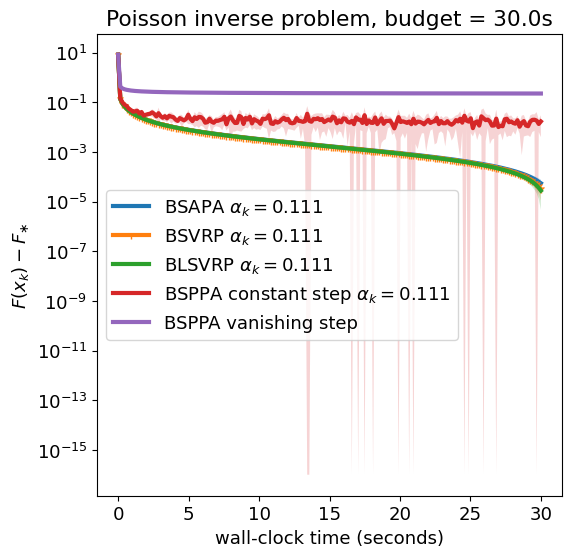


Running j = 2.0, step_size = 2.2222e-01, time budget = 30.00s
  run 1/10 done
  run 2/10 done
  run 3/10 done
  run 4/10 done
  run 5/10 done
  run 6/10 done
  run 7/10 done
  run 8/10 done
  run 9/10 done
  run 10/10 done


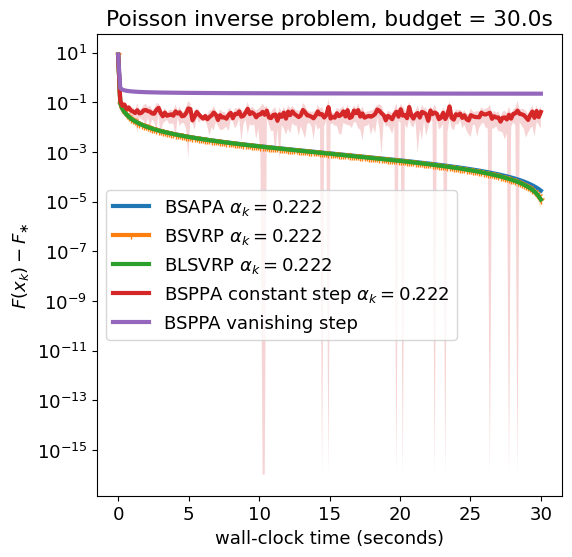


Running j = 3.0, step_size = 3.3333e-01, time budget = 30.00s
  run 1/10 done
  run 2/10 done
  run 3/10 done
  run 4/10 done
  run 5/10 done
  run 6/10 done
  run 7/10 done
  run 8/10 done
  run 9/10 done
  run 10/10 done


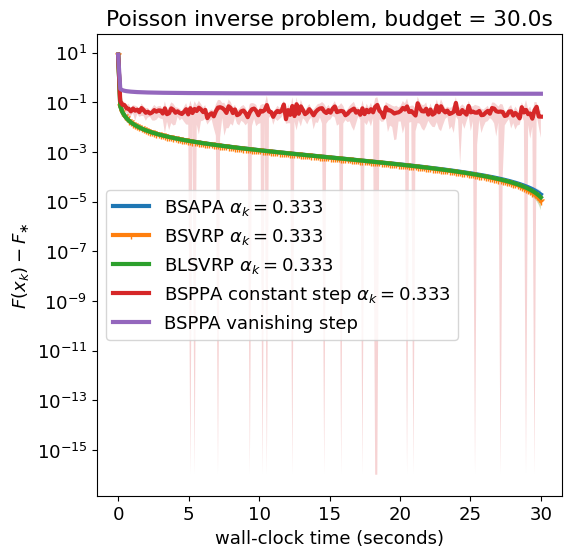


Running j = 4.0, step_size = 4.4444e-01, time budget = 30.00s
  run 1/10 done
  run 2/10 done
  run 3/10 done
  run 4/10 done
  run 5/10 done
  run 6/10 done
  run 7/10 done
  run 8/10 done
  run 9/10 done
  run 10/10 done


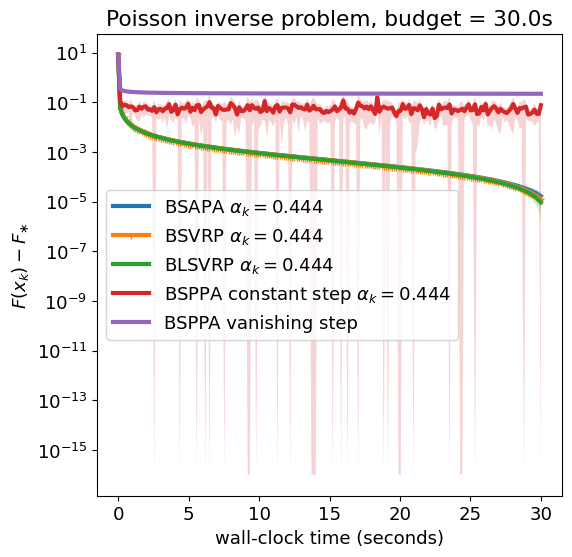

In [5]:
def get_stepsize_label(j):
    tmp = 1.0 / j
    if np.isclose(j, 5):
        return r"$\alpha_k = 1/L$"
    elif np.isclose(j, 10) or np.isclose(j, 25):
        return r"$\alpha_k = {}/L$".format(int(j / 5 + 0.3))
    else:
        return r"$\alpha_k = 1/{}L$".format(int(5 * tmp + 0.3))

import math
import os

def truncate(x, decimals=0):
    factor = 10.0 ** decimals
    return math.trunc(x * factor) / factor

def interpolate_histories_on_common_time(hist_list, time_budget_seconds, n_grid=200):
    """
    Histories have different numbers of logged points because each method has
    a different loop structure and different per-iteration cost. To average
    runs fairly, interpolate each run on the same wall-clock grid.
    """
    time_grid = np.linspace(0.0, time_budget_seconds, n_grid)
    values = np.full((len(hist_list), n_grid), np.nan, dtype=float)

    for r, hist in enumerate(hist_list):
        t = np.asarray(hist["time"], dtype=float)
        y = np.asarray(hist["obj"], dtype=float)
        if len(t) == 0:
            continue

        # Remove duplicate times before interpolation.
        t_unique, idx = np.unique(t, return_index=True)
        y_unique = y[idx]

        # Hold the last observed value after the last logged time.
        values[r] = np.interp(
            time_grid,
            t_unique,
            y_unique,
            left=y_unique[0],
            right=y_unique[-1],
        )

    return time_grid, np.nanmean(values, axis=0), np.nanstd(values, axis=0)

def plot_mean_std(ax, x, mean, std, f_star, label, use_shading=True, marker=None):
    y = np.maximum(mean - f_star, 1e-16)
    ax.plot(x, y, label=label, marker=marker)

    if use_shading:
        y_low = np.maximum(mean - std - f_star, 1e-16)
        y_high = np.maximum(mean + std - f_star, 1e-16)
        ax.fill_between(x, y_low, y_high, alpha=0.2)

rng = np.random.default_rng(42)

# Toggle shading here
use_shading = True

n, d = 100, 100

A = np.random.rand(n, d)
x_true = np.random.rand(d)

Ax_true = A @ x_true

b = rng.poisson(np.maximum(Ax_true, 1e-3)).astype(float)
b = np.maximum(b, 1e-8)

x0 = np.ones(d)

L = b.max()

# Wall-clock budget shared by every algorithm and every run.
# Change this value to decide how long each algorithm is allowed to run.
TIME_BUDGET_SECONDS = 30.0

# Kept as a fallback only. If TIME_BUDGET_SECONDS is not None, the algorithms
# stop by time, not by maxepochs.
maxepochs = 2000
n_runs = 10
base_seed = 42

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["font.size"] = 13
plt.rcParams["lines.linewidth"] = 3

os.makedirs("Plots", exist_ok=True)

for j in [1., 2., 3., 4.]:
    tmp = 1.0 / (20*j)
    step_size = 1.0 / (5 * tmp * L)

    print(f"\nRunning j = {j}, step_size = {step_size:.4e}, time budget = {TIME_BUDGET_SECONDS:.2f}s")

    all_sapa = []
    all_svrp = []
    all_lsvrp = []
    all_sppa = []
    all_sppa_v = []

    for run in range(n_runs):
        seed = base_seed + 10*run

        _, hist_sapa = bregman_sapa_kl(
            A=A,
            b=b,
            x0=x0,
            stepsize=step_size,
            max_epochs=maxepochs,
            time_budget_seconds=TIME_BUDGET_SECONDS,
            seed=seed,
            verbose=False,
        )

        _, hist_svrp = bregman_svrp_kl(
            A=A,
            b=b,
            x0=x0,
            stepsize=step_size,
            max_epochs=maxepochs,
            inner_steps=n,
            time_budget_seconds=TIME_BUDGET_SECONDS,
            seed=seed,
            verbose=False,
        )

        _, hist_lsvrp = bregman_lsvrp_kl(
            A=A,
            b=b,
            x0=x0,
            stepsize=step_size,
            max_epochs=maxepochs,
            time_budget_seconds=TIME_BUDGET_SECONDS,
            seed=seed,
            verbose=False,
        )

        _, hist_sppa = bregman_sppa_kl(
            A=A,
            b=b,
            x0=x0,
            stepsize=step_size,
            max_epochs=maxepochs,
            time_budget_seconds=TIME_BUDGET_SECONDS,
            seed=seed,
            verbose=False,
            vanishing=False,
        )

        _, hist_sppa_vanishing = bregman_sppa_kl(
            A=A,
            b=b,
            x0=x0,
            stepsize=step_size,
            max_epochs=maxepochs,
            time_budget_seconds=TIME_BUDGET_SECONDS,
            seed=seed,
            verbose=False,
        )

        all_sapa.append(hist_sapa)
        all_svrp.append(hist_svrp)
        all_lsvrp.append(hist_lsvrp)
        all_sppa.append(hist_sppa)
        all_sppa_v.append(hist_sppa_vanishing)

        print(f"  run {run + 1}/{n_runs} done")

    f_star = min(
        min(np.min(h["obj"]) for h in all_sapa),
        min(np.min(h["obj"]) for h in all_svrp),
        min(np.min(h["obj"]) for h in all_lsvrp),
        min(np.min(h["obj"]) for h in all_sppa),
        min(np.min(h["obj"]) for h in all_sppa_v),
    )

    time_grid, mean_sapa, std_sapa = interpolate_histories_on_common_time(all_sapa, TIME_BUDGET_SECONDS)
    _, mean_svrp, std_svrp = interpolate_histories_on_common_time(all_svrp, TIME_BUDGET_SECONDS)
    _, mean_lsvrp, std_lsvrp = interpolate_histories_on_common_time(all_lsvrp, TIME_BUDGET_SECONDS)
    _, mean_sppa, std_sppa = interpolate_histories_on_common_time(all_sppa, TIME_BUDGET_SECONDS)
    _, mean_sppa_v, std_sppa_v = interpolate_histories_on_common_time(all_sppa_v, TIME_BUDGET_SECONDS)

    fig, ax = plt.subplots()

    label_suffix = r"$\alpha_k = {}$".format(truncate(step_size, 3))

    plot_mean_std(ax, time_grid, mean_sapa, std_sapa, f_star, f"BSAPA {label_suffix}", use_shading)
    plot_mean_std(ax, time_grid, mean_svrp, std_svrp, f_star, f"BSVRP {label_suffix}", use_shading, marker="1")
    plot_mean_std(ax, time_grid, mean_lsvrp, std_lsvrp, f_star, f"BLSVRP {label_suffix}", use_shading)
    plot_mean_std(ax, time_grid, mean_sppa, std_sppa, f_star, f"BSPPA constant step {label_suffix}", use_shading)
    plot_mean_std(ax, time_grid, mean_sppa_v, std_sppa_v, f_star, "BSPPA vanishing step", use_shading)

    ax.set_yscale("log")
    ax.set_ylabel(r"$F(x_k) - F_{\ast}$")
    ax.set_xlabel("wall-clock time (seconds)")
    ax.set_title(f"Poisson inverse problem, budget = {TIME_BUDGET_SECONDS:.1f}s")
    ax.legend()

    suffix = "_shaded" if use_shading else ""
    fig.savefig("Plots/poisson_{}_avg_{}_bsppa_vs_varred_wall_clock.png".format(j, suffix), bbox_inches="tight", dpi=200)
    plt.show()
    plt.close()
